# O_6 - final questions

**Question:** measure how predictable a dropback is from the game state - score, down, distance-to-first, distance-to-goal, time left, then work out how much that number moves when the offense lines up in a particular formation.

**Plan**

1. Fit two models: game-state only, and game-state + formation.
2. formation_swing = P(dropback | state + formation) - P(dropback | state) per play. Average by formation.
3. Check whether that swing depends on the situation (trailing big? red zone? two-minute?).
4. Read the formation odds ratios now that score / distance / time are controlled for.
5. Rank the most predictable dropback and run looks.
6. Write up.

In [7]:
#setup
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from dropback_analysis.features import build_features
from dropback_analysis.models import fit_logistic_regression, odds_ratio_table, predict_dropback_probability

DATA = '/Users/seanlee/Desktop/Github_repositories/Practice-repo/data'
plays = pd.read_csv(f'{DATA}/plays.csv')
games = pd.read_csv(f'{DATA}/games.csv')

features = build_features(plays, games)   # note: build_features now needs games too
print(features.shape)
features[['down', 'yardsToGoBucket', 'scoreDiffBucket', 'yardsToGoalBucket', 'timeBucket', 'offenseFormation', 'isDropback']].head()

(15816, 10)


,down,yardsToGoBucket,scoreDiffBucket,yardsToGoalBucket,timeBucket,offenseFormation,isDropback
0,1,long,leading_big,backed_up,normal,EMPTY,True
1,1,long,tied,backed_up,late_half,EMPTY,True
2,3,long,trailing_big,backed_up,two_minute,SHOTGUN,True
3,2,long,tied,midfield,normal,SHOTGUN,True
4,2,long,tied,midfield,normal,PISTOL,False


## 1. Two models: game state alone vs game state + formation

full is the O_5 model (everything). situation drops the formation term, so its prediction is "how predictable is this dropback from the situation alone". The gap between them is the formation's contribution.

In [8]:
#fit two models: game state only, and game state + formation
situation = smf.logit(
    "isDropback.astype(int) ~ C(down, Treatment(1)) + C(yardsToGoBucket, Treatment('short')) "
    "+ C(scoreDiffBucket, Treatment('tied')) + C(yardsToGoalBucket, Treatment('midfield')) "
    "+ C(timeBucket, Treatment('normal'))",
    data=features,
).fit()

full = fit_logistic_regression(features)   # the same terms + C(offenseFormation)

scored = features.copy()
scored['p_situation'] = situation.predict(features)   # predictability from the game state alone
scored['p_full'] = full.predict(features)             # predictability once you also see the formation
scored['formation_swing'] = scored['p_full'] - scored['p_situation']

scored.groupby('offenseFormation').agg(
    n=('formation_swing', 'size'),
    p_situation=('p_situation', 'mean'),
    mean_p_full=('p_full', 'mean'),
    mean_swing=('formation_swing', 'mean')

).sort_values('mean_swing', ascending=False).round(3)

Optimization terminated successfully.
         Current function value: 0.590718
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.524540
         Iterations 7


,n,p_situation,mean_p_full,mean_swing
offenseFormation,,,,
EMPTY,1341,0.708,0.966,0.257
SHOTGUN,8791,0.662,0.745,0.083
PISTOL,641,0.528,0.353,-0.176
SINGLEBACK,3842,0.521,0.340,-0.181
I_FORM,1012,0.511,0.295,-0.215
JUMBO,110,0.437,0.191,-0.246
WILDCAT,79,0.501,0.165,-0.336


In [9]:
scored = scored.merge(plays[['gameId', 'playId', 'yardsGained']], on=['gameId', 'playId'], how='left')

need = np.select(
    [scored['down'] == 1, scored['down'] == 2],
    [0.4 * scored['yardsToGo'], 0.6 * scored['yardsToGo']],
    default=scored['yardsToGo'],          # 3rd & 4th down: you need the whole distance
)
scored['successful'] = scored['yardsGained'] >= need

# sanity check: success rate for dropbacks vs handoffs, and by how predictable the dropback was
print(scored.groupby('isDropback')['successful'].agg(['mean', 'size']).round(3))
print()
tier = pd.cut(scored['p_full'], [0, 0.5, 0.7, 0.85, 1.0], labels=['coin-flip', 'lean', 'likely', 'near-certain'])
print(scored[scored['isDropback']].groupby(tier, observed=True)['successful'].agg(['mean', 'size']).round(3))

             mean  size
isDropback             
False       0.498  6103
True        0.468  9713

               mean  size
p_full                   
coin-flip     0.522  1919
lean          0.535  1637
likely        0.482  3105
near-certain  0.383  3052


In [10]:
#step 3: within a fixed situation, what each formation tells the defense and how the offense does

def formation_cut(df, label):
    out = (
        df.groupby('offenseFormation')
        .agg(plays=('successful', 'size'),
             p_dropback=('p_full', 'mean'),        # what the defense reads pre-snap
             dropback_rate=('isDropback', 'mean'), # what the offense actually did
             success_rate=('successful', 'mean'))  # did the play work
        .loc[lambda t: t['plays'] >= 20]           # ignore tiny samples
        .sort_values('p_dropback', ascending=False)
        .round(3)
    )
    print(f'\n {label}   (n={len(df)})')
    print(out)

formation_cut(scored[(scored.down == 3) & (scored.yardsToGoBucket == 'short')], '3rd & short')
formation_cut(scored[(scored.down == 3) & (scored.yardsToGoBucket == 'long')],  '3rd & long')
formation_cut(scored[(scored.down == 2) & (scored.yardsToGoBucket == 'long')],  '2nd & long')
formation_cut(scored[scored.yardsToGoalBucket == 'red_zone'],                    'red zone (any down)')


 3rd & short   (n=892)
                  plays  p_dropback  dropback_rate  success_rate
offenseFormation                                                
EMPTY                77       0.953          0.922         0.519
SHOTGUN             534       0.706          0.652         0.545
PISTOL               28       0.381          0.107         0.714
SINGLEBACK          159       0.368          0.308         0.597
I_FORM               71       0.325          0.211         0.634

 3rd & long   (n=1250)
                  plays  p_dropback  dropback_rate  success_rate
offenseFormation                                                
EMPTY               240       0.989          0.988         0.204
SHOTGUN             974       0.907          0.938         0.249
SINGLEBACK           22       0.710          0.273         0.091

 2nd & long   (n=2768)
                  plays  p_dropback  dropback_rate  success_rate
offenseFormation                                                
EMPTY             

In [11]:
#step 4: is the "pass tell" cost real?  group formations, compare success, test the gap
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

OBVIOUS    = ['EMPTY', 'SHOTGUN']                 # defense reads pass
RUN_THREAT = ['SINGLEBACK', 'I_FORM', 'PISTOL']   # run still on the table

def coach_table(df, label):
    t = (df[df.offenseFormation.isin(OBVIOUS + RUN_THREAT)]
         .groupby('offenseFormation')
         .agg(plays=('successful', 'size'),
              defense_reads_pass=('p_full', 'mean'),
              success_rate=('successful', 'mean'))
         .loc[lambda x: x.plays >= 20]
         .sort_values('defense_reads_pass', ascending=False)
         .round(3))
    print(f'\n{label}\n{t}')

def tell_cost(df, label):
    obv = df[df.offenseFormation.isin(OBVIOUS)]
    run = df[df.offenseFormation.isin(RUN_THREAT)]
    s, n = [obv.successful.sum(), run.successful.sum()], [len(obv), len(run)]
    _, p = proportions_ztest(s, n)
    lo, hi = confint_proportions_2indep(s[1], n[1], s[0], n[0])   # run minus obvious
    print(f'\n{label}')
    print(f'  obvious-pass (EMPTY/SHOTGUN):   {s[0]/n[0]:.3f}   (n={n[0]})')
    print(f'  gap {s[1]/n[1] - s[0]/n[0]:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]   p={p:.3f}')

for label, df in [
    ('3rd & short', scored[(scored.down == 3) & (scored.yardsToGoBucket == 'short')]),
    ('red zone',    scored[scored.yardsToGoalBucket == 'red_zone']),
    ('3rd & long (control - no run alternative)',
                    scored[(scored.down == 3) & (scored.yardsToGoBucket == 'long')]),
]:
    coach_table(df, label)
    tell_cost(df, label)


3rd & short
                  plays  defense_reads_pass  success_rate
offenseFormation                                         
EMPTY                77               0.953         0.519
SHOTGUN             534               0.706         0.545
PISTOL               28               0.381         0.714
SINGLEBACK          159               0.368         0.597
I_FORM               71               0.325         0.634

3rd & short
  obvious-pass (EMPTY/SHOTGUN):   0.542   (n=611)
  gap +0.078   95% CI [+0.006, +0.148]   p=0.033

red zone
                  plays  defense_reads_pass  success_rate
offenseFormation                                         
EMPTY               172               0.960         0.401
SHOTGUN            1275               0.706         0.417
PISTOL              109               0.338         0.523
SINGLEBACK          520               0.305         0.473
I_FORM              139               0.265         0.496

red zone
  obvious-pass (EMPTY/SHOTGUN):   0.415   (

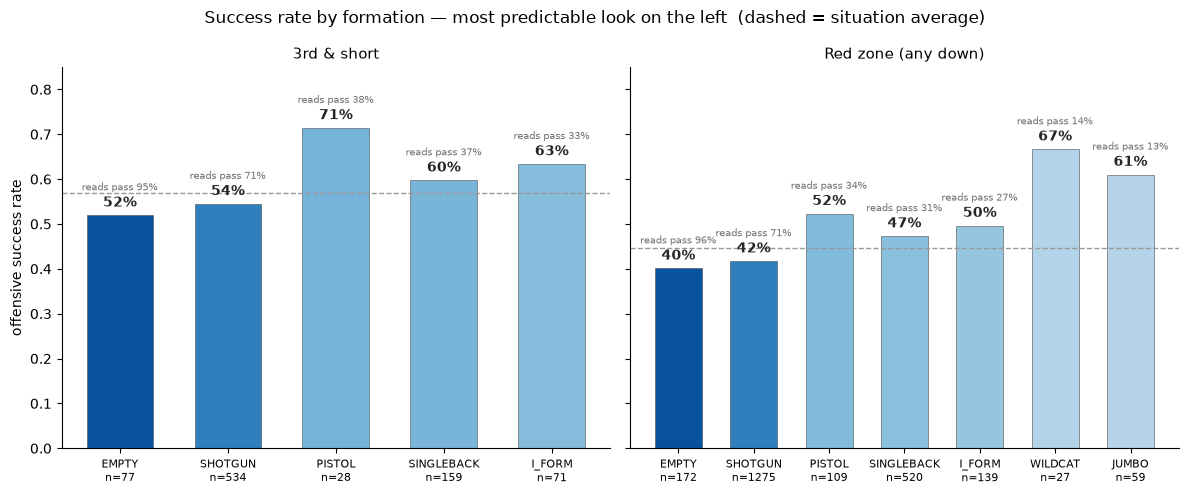

In [12]:
#success rate by formation, most predictable look on the left
import matplotlib as mpl
import matplotlib.pyplot as plt

def summary(df):
    return (df.groupby('offenseFormation')
            .agg(plays=('successful', 'size'),
                 reads_pass=('p_full', 'mean'),
                 success=('successful', 'mean'))
            .loc[lambda x: x.plays >= 20]
            .sort_values('reads_pass', ascending=False))

panels = [
    ('3rd & short', scored[(scored.down == 3) & (scored.yardsToGoBucket == 'short')]),
    ('Red zone (any down)', scored[scored.yardsToGoalBucket == 'red_zone']),
]

norm = mpl.colors.Normalize(0.2, 1.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (label, df) in zip(axes, panels):
    s = summary(df)
    colors = plt.cm.Blues(0.35 + 0.55 * norm(s['reads_pass'].to_numpy()))  # darker = more predictable
    ax.bar(range(len(s)), s['success'], color=colors, edgecolor='0.3', linewidth=0.4, width=0.62)
    ax.axhline(df['successful'].mean(), color='0.6', lw=1, ls='--')        # situation average

    for i, row in enumerate(s.itertuples()):
        ax.text(i, row.success + 0.012, f'{row.success:.0%}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='0.15')
        ax.text(i, row.success + 0.05, f'reads pass {row.reads_pass:.0%}', ha='center', va='bottom',
                fontsize=7.5, color='0.45')

    ax.set_xticks(range(len(s)))
    ax.set_xticklabels([f'{f}\nn={int(n)}' for f, n in zip(s.index, s['plays'])], fontsize=8)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 0.85)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('offensive success rate')
fig.suptitle('Success rate by formation — most predictable look on the left  (dashed = situation average)',
             fontsize=12)
plt.tight_layout()
plt.show()


**Question.** How much does the offense's formation raise the defense's read that a dropback is coming; beyond what down, distance, score, field position and clock already say, and does giving away that tell cost the offense?

**Method.**
- Two logistic models of isDropback: game state only, and game state + formation. formation_swing = P(dropback | state + formation) − P(dropback | state).
- success = standard on-schedule rule (≥ 40% of the distance on 1st
down, 60% on 2nd, 100% 3rd-4th)
- Compared "obvious pass" formations (EMPTY, SHOTGUN) vs "run-threat"
formations (SINGLEBACK,PISTOL, I-FORM, JUMBO, WILDCAT) fixed situations, so any gap is the formation's doing, not the down-and-distance.

**Formation swing — P(dropback) added over game state alone.**

| EMPTY | SHOTGUN | PISTOL | SINGLEBACK | I-FORM | JUMBO | WILDCAT |
|---|---|---|---|---|---|---|
| +0.26 | +0.08 | −0.18 | −0.18 | −0.22 | −0.25 | −0.34 |

**Does the tell cost the offense?**

| situation | obvious-pass success | run-threat success | gap | p |
|---|---|---|---|---|
| Red zone | 41.5% (n=1447) | 48.4% (n=768) | **+6.9 pts** | 0.002 |
| 3rd & short | 54.2% (n=611) | 62.0% (n=258) | **+7.8 pts** | 0.033 |
| 3rd & long *(control)* | 24.1% (n=1214) | 11.8% (n=22) | −12.3 pts | 0.097 (n.s.) |

**Takeaways.**
1. A pass tell costs ~7 points of success rate, but only where a credible run alternative exists (short yardage, red zone). Red zone is the more reliable finding.
2. On 3rd-and-long the ay: you're passing regardless, and success is just low because the down is hard.
3. Worst combos in the rt (defense reads pass95%, 51.9% success) and EMPTY in the red zone (96%, 40.1%).

**Coach line.** On 3rd-and-short and in the red zone, empty / plain shotgun sets tip the pass 70–95% of the time and succeed from 42–54%. Keeping a back in the picture drops the defense's pass read to approximately 30–38% and lifts success to 48–62% — about a 7-point swing.